Pulling financial data...

=== Financial Comparison ===



,Company,Symbol,Sector,Price,Market Cap,Revenue,Net Income,EPS,Gross Margin %,Operating Margin %,Net Margin %,ROE,ROIC,EV/EBITDA,Earnings Yield,Current Ratio,Net Debt/EBITDA
0,Apple Inc.,AAPL,Technology,247.99,3818743810000,416161000000,112010000000,7.46,46.91,31.97,26.92,1.51913,0.519684,26.969935,0.029332,0.893293,0.529285


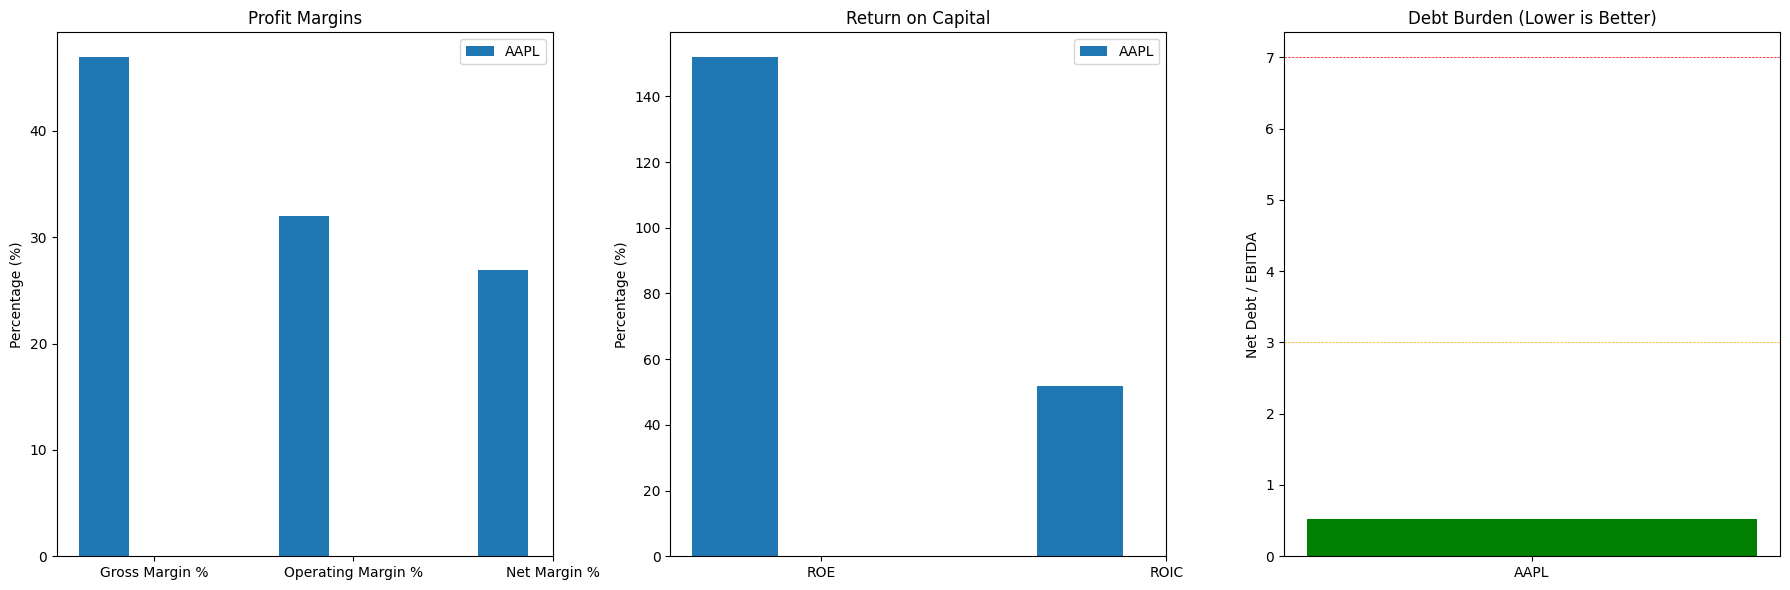


=== AI Analysis ===

Apple Inc. demonstrates exceptional profitability, boasting a gross margin of 46.91%, operating margin of 31.97%, and a net margin of 26.92%. Its return on equity (ROE) is an outstanding 151.91% and return on invested capital (ROIC) is a very strong 51.97%, indicating highly efficient use of capital. Financially, its net debt to EBITDA is low at 0.53, suggesting a healthy debt load. However, a current ratio of 0.89 indicates potential short-term liquidity considerations, though this can be managed by its strong cash generation. Valuation metrics suggest the stock is expensive, with an EV/EBITDA of 26.97 and an earnings yield of 2.93%.

**Final Ranking Section**
As data for only one company was provided, a comparative ranking of multiple companies is not possible.


In [26]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import ai
def full_analysis(companies):
    # 1. Pull data
    print("Pulling financial data...")
    rows = [analyze_company(s) for s in companies]
    rows = [r for r in rows if r is not None]
    df = pd.DataFrame(rows)

    # 2. Display table
    print("\n=== Financial Comparison ===\n")
    display(df)

    # 3. Charts
    categories = ["Gross Margin %", "Operating Margin %", "Net Margin %"]
    x = range(len(categories))
    width = 0.25

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Margins chart
    for i, row in df.iterrows():
        values = [row[cat] for cat in categories]
        offset = (i - 1) * width
        axes[0].bar([p + offset for p in x], values, width, label=row["Symbol"])
    axes[0].set_ylabel("Percentage (%)")
    axes[0].set_title("Profit Margins")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(categories)
    axes[0].legend()
    axes[0].axhline(y=0, color="black", linewidth=0.5)

    # Return on capital chart
    metrics = ["ROE", "ROIC"]
    x2 = range(len(metrics))
    for i, row in df.iterrows():
        values = [row[m] * 100 for m in metrics]
        offset = (i - 1) * width
        axes[1].bar([p + offset for p in x2], values, width, label=row["Symbol"])
    axes[1].set_ylabel("Percentage (%)")
    axes[1].set_title("Return on Capital")
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(metrics)
    axes[1].legend()
    axes[1].axhline(y=0, color="black", linewidth=0.5)

    # Debt chart
    symbols = df["Symbol"].tolist()
    debt_values = df["Net Debt/EBITDA"].tolist()
    colors = ["green" if v < 3 else "orange" if v < 7 else "red" for v in debt_values]
    axes[2].bar(symbols, debt_values, color=colors)
    axes[2].set_ylabel("Net Debt / EBITDA")
    axes[2].set_title("Debt Burden (Lower is Better)")
    axes[2].axhline(y=3, color="orange", linewidth=0.5, linestyle="--")
    axes[2].axhline(y=7, color="red", linewidth=0.5, linestyle="--")

    plt.tight_layout()
    plt.show()

    # 4. LLM Analysis
    print("\n=== AI Analysis ===\n")
    data_text = df.to_string()

    prompt = f"""You are a financial analyst. Here is financial data for several companies:

{data_text}

Weight these factors in order of importance:
1. Profitability (margins, ROE, ROIC) - most important
2. Financial health (debt levels, current ratio) - second
3. Valuation (EV/EBITDA, earnings yield) - third

A highly profitable company with high debt is riskier than a moderately profitable company with no debt. A cheap stock that is unprofitable is not a good value.

Output format:
- One short paragraph per company summarizing its overall picture (strengths, weaknesses, red flags) with specific numbers inline
- Then a final ranking section that directly compares the companies against each other, explaining why #1 beats #2 and #2 beats #3
- Be concise. No category-by-category breakdown per company.
- Present numbers as percentages where appropriate (e.g., 29.65% not 0.2965)
- No letter formatting, greetings, or dates"""

    response = ai.generate_text(prompt)
    print(response)

# Run it
full_analysis(["AAPL"])